In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [4]:
with open('2014.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)

In [17]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('страна', 108), ('брикс', 83), ('наш', 83), ('развитие', 72), ('сотрудничество', 59), ('год', 52), ('международный', 52), ('цель', 52), ('область', 50), ('вопрос', 44), ('оон', 43), ('который', 42), ('обеспечение', 42), ('также', 42), ('связь', 35), ('призывать', 35), ('экономический', 34), ('устойчивый', 33), ('усилие', 33), ('приветствовать', 33), ('безопасность', 31), ('решение', 31), ('рамка', 30), ('мир', 30), ('заявлять', 28), ('вновь', 27), ('создание', 27), ('проблема', 27), ('поддержка', 26), ('глобальный', 25), ('важный', 23), ('совещание', 23), ('право', 22), ('организация', 22), ('экономика', 22), ('основа', 21), ('финансовый', 21), ('национальный', 21), ('должный', 21), ('сторона', 20), ('встреча', 20), ('рост', 19), ('новый', 19), ('процесс', 19), ('совет', 19), ('саммит', 18), ('роль', 18), ('политический', 18), ('возможность', 18), ('группа', 18), ('выражать', 18), ('проведение', 18), ('необходимость', 17), ('подтверждать', 17), ('диалог',

C:\Temp\ipykernel_8676\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


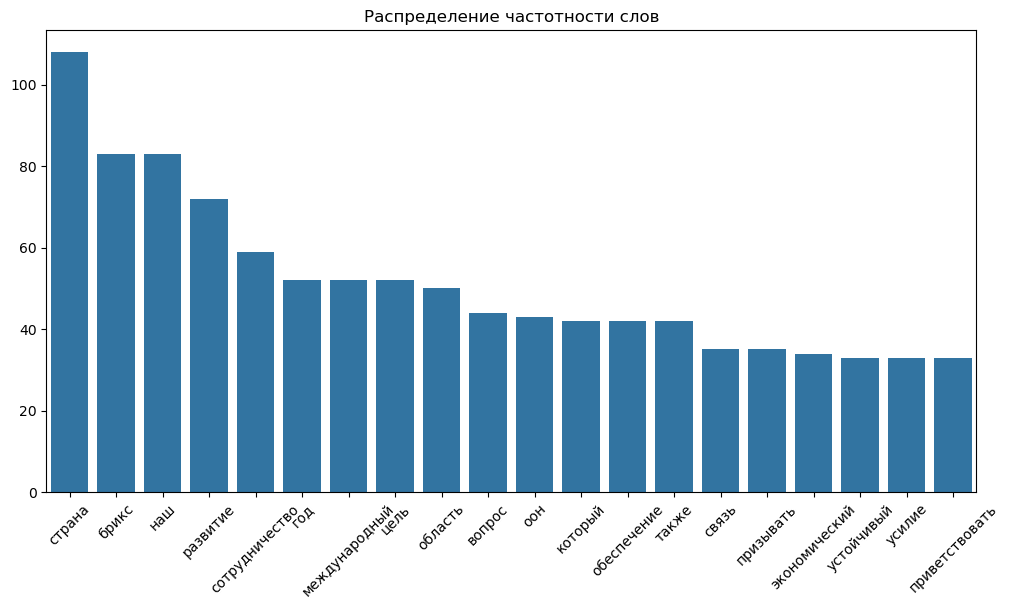

In [19]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [21]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [23]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_8676\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


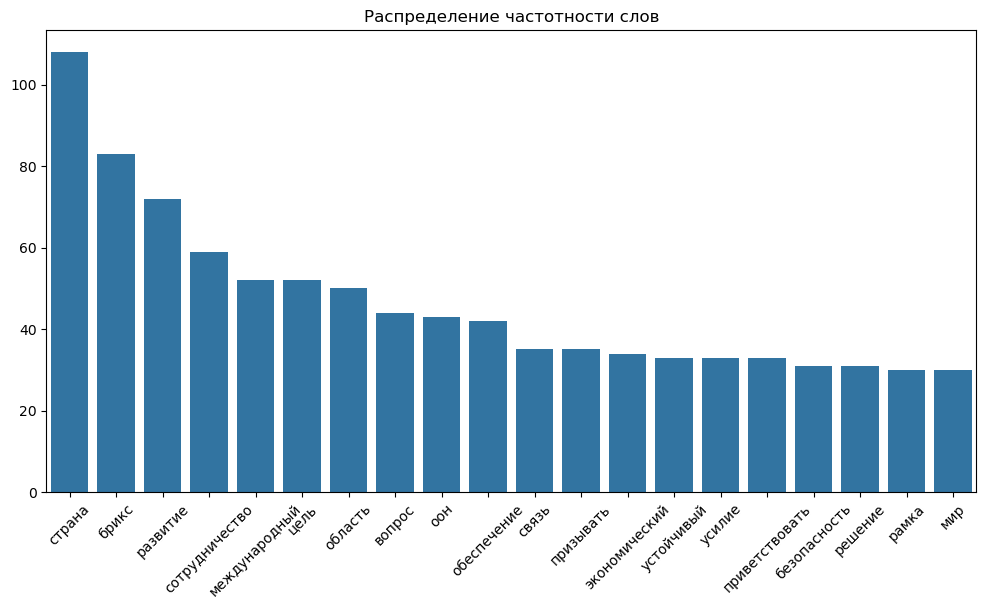

In [25]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [27]:
textt = ','.join(w for w in tokens)

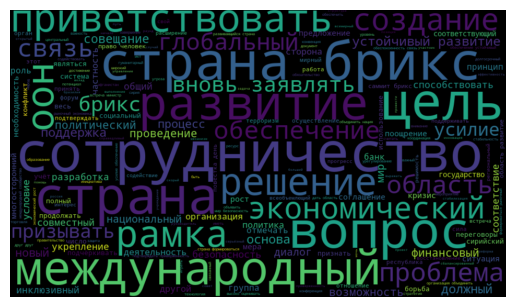

In [29]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [34]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [35]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['безопасность', 'устойчивый', 'призывать', 'область', 'международный', 'цель', 'сотрудничество', 'развитие', 'брикс', 'страна']


Top 10 words for topic #1:
['поддержка', 'вновь', 'создание', 'приветствовать', 'усилие', 'экономический', 'связь', 'обеспечение', 'оон', 'вопрос']




In [38]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['рамка', 'мир', 'безопасность', 'устойчивый', 'призывать', 'область', 'цель', 'международный', 'сотрудничество', 'развитие']


Top 10 words for topic #1:
['организация', 'экономика', 'важный', 'глобальный', 'поддержка', 'создание', 'экономический', 'связь', 'обеспечение', 'вопрос']


Top 10 words for topic #2:
['встреча', 'финансовый', 'совещание', 'вновь', 'решение', 'усилие', 'приветствовать', 'оон', 'брикс', 'страна']




### Неотрицательная матричная факторизация

In [108]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['укрепление', 'экономика', 'бразилия', 'поддерживать', 'вопрос', 'африка', 'китай', 'встреча', 'международный', 'сотрудничество']


Top 10 words for topic #1:
['рамка', 'индия', 'экономика', 'вопрос', 'китай', 'проведение', 'страна', 'развитие', 'международный', 'брикс']




Вывод: тематика декларации 2014 г. посвящена общим вопросам международного сотрудничества